# Airbnb Analysis
## Teresa Ferrill, December 7, 2025

Data Analysis and Visualization using Python.   

With the Airbnb dataset, performed the following steps using Python:  
>1. Summarized the data then explored two different questions.  
>2. Created a histogram from the data.  
>3. Createe a boxplot from the data.
>4. Created a bivariate plot from the data.  
>5. Created additional visualizations that support the questions answered.
>6. Summary of results, explaining how conclusion was drawn and how the visualizations support conclusion.  

The dataset used for this assignment is a curated Airbnb Open Data sample (approximately 100,000 rows).  
Data set file: AB_NYC_2019.csv  (https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data?resource=download)  
>Context of dataset: Since 2008, guests and hosts have used Airbnb to expand on traveling possibilities and present more unique, personalized way of experiencing the world. This dataset describes the listing activity and metrics in NYC, NY for 2019.  

Questions to visually explore the data:  
>Q1: What is the distribution of Airbnb listing prices?  Histogram   
>Q2: How do prices vary across different room types?  Boxplot  
>Q3: Is there a relationship between a listing’s price and its number of reviews?  Bivariate scatterplot
>Q4: What is the relationship between the price and the location of the Airbnb?  Boxplot 

-----------------------------------------------------------------------------------------------------------------
Basic dataset cleaning steps, part 1:  
> Load dataset  
> Identify number of rows and columns  
> Review columns and data

In [1]:
# Load dataset

# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set default style for all plots in the script to 
# a white background with grey grid lines
sns.set(style="whitegrid")  

# Load the dataset
df = pd.read_csv("../data/AB_NYC_2019.csv")

# Identify number of rows and columns
num_rows, num_cols = df.shape

# Print number of rows and columns
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}\n")

# Review columns and data
print(df.head())
print(df.info())

Number of rows: 48895
Number of columns: 16

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room 

This initial block of code begins the exploration of the dataset.   
>The import statements include those libraries needed to support the plots required in steps 2 through 5

>The default style for all plots in all script blocks is standardized to a white background with grey grid lines, ensuring a consistent graph presentation style throughout all code  
  
>The dataset loaded without error or warning.
  
>Finally, general information about the dataset is computed and printed, providing helpful information for consideration in completing the data cleaning process  
>>1. Identify the number of rows and columns  
>>2. Print out of number of rows and columns  
>>3. A review columns and data

Side notes:  
This summary indicates that the dataset contains 48,895 Airbnb listings.  There are 16 columns capturing a mix of listing information, host details, geographic coordinates, and activity metrics.  The info() output shows that most columns are complete, with nearly all listings containing values for critical fields such as price, room_type, neighbourhood, and availability.  Only two columns—last_review and reviews_per_month—contain missing values, each with around 10,000 null entries.  This would suggest many listings have never been reviewed, indicating review-based features may need imputation or special handling if they are used during analysis.  

The dataset includes a combination of numeric (int64, float64) and categorical (object) data types.  Numeric fields such as price, minimum_nights, number_of_reviews, and availability_365 are ready for statistical analysis.  If used in modeling, I will have to perform encoding or grouping  on the categorical variables (including room_type, neighbourhood_group, and host_name).  Overall, I believe the structure  of the dataset is relatively clean and suitable for exploratory data analysis, descriptive statistics, and predictive modeling.  I will have to ensure that any missing values and categorical variables are handled appropriately.  

I will begin next steps by performing an exploratory data analysis (EDA) - checking for missing values, evaluating distributions of key numerical variables, identifing outliers, and reviewing correlations between features.  I will also review the dataset by handling missing data and identifying outliers that can skew analytical results.  Once these preparation steps are completed, I will work to form hypotheses and identify which variables may be most useful for predictive modeling or visualization.

-----------------------------------------------------------------------------------------------------------------
Basic dataset cleaning steps, part 2:  
> Select and retain columns to support analysis  
> Remove duplicate rows   
> Remove zero and negative prices  

In [2]:
# Keep only those columns to support analysis
df = df[["price", "room_type", "neighbourhood",
         "neighbourhood_group",
         "minimum_nights", "number_of_reviews", 
         "reviews_per_month", "availability_365"]]

# Remove duplicate rows
print("Shape with specified features:", df.shape)

# Remove fully duplicated rows
print("\nNumber of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicate rows:", df.shape)

# Check how many invalid prices exist before removal
invalid_count = df[df["price"] <= 0].shape[0]
print("\nNumber of zero or negative price rows:", invalid_count)

# Remove rows with zero or negative prices
df = df[df["price"] > 0]

# Confirm the result
print("Shape after removing zero/negative prices:", df.shape)
print("Minimum remaining price:", df["price"].min())

# Print results of basic cleaning
print("\nRows after cleaning:", df.shape)

Shape with specified features: (48895, 8)

Number of duplicate rows: 1216
Shape after removing duplicate rows: (47679, 8)

Number of zero or negative price rows: 11
Shape after removing zero/negative prices: (47668, 8)
Minimum remaining price: 10

Rows after cleaning: (47668, 8)


This block of code completes the exploration of the dataset.  
>Keep the features chosen to support analysis.  
>>Features selected include price, room type, neighbourhood, neighbourhood group, minimum nights, number of reviews, reviews per month, and availability 365.  

>Print out the resulting shape of the dataset after narrowing features  
>Check for duplicate rows, removing fully duplicated rows  
>Review the Price feature and remove zero and null values from dataset   
>Print the results of the basic cleaning efforts  

Side notes:  
I have narrowed the dataset to only the variables I believe are relevant for analysis.  This helps reduce noise and ensure further processing focuses on features most likely to influence price, demand, or listing performance.  
>These features were selected because they represent the core factors that influence Airbnb listing behavior, pricing, and demand.

>>1. Price is the primary variable of interest in most Airbnb analyses, while room type, neighbourhood, and neighbourhood group provide essential context about the property’s location and accommodation style.  Together, these are two of the strongest drivers of pricing differences.  
>>2. Minimum nights helps capture booking restrictions that may affect how attractive or accessible a listing is to guests.  
>>3. Number of reviews and reviews per month serve as indicators of listing popularity and activity, offering insight into guest demand and host performance.  
>>4. Finally, availability_365 reflects host booking patterns and market saturation, showing how often a listing is open throughout the year.  

>Together, I believe these features offer a balanced mix of pricing inputs, location-based attributes, demand indicators, and host behavior metrics. They are among the most commonly used and most predictive fields in Airbnb analytics, making them highly relevant for exploratory analysis, visualizations, and potential predictive modeling.  

I then reviewed the price feature and removed those rows with a price of zero or if the price is missing.  
>These rows were removed as they represent invalid or non-meaningful listings that would distort averages, histograms, and predictive models.   

Overall, these transformations will improve data integrity and create a cleaner, more reliable dataset that is ready for exploratory analysis, visualization, and eventual modeling.  

-----------------------------------------------------------------------------------------------------------------
*2. Create a histogram*  
***Note*** - A histogram is appropriate for price distributions - this graph treats every price value as a category.  

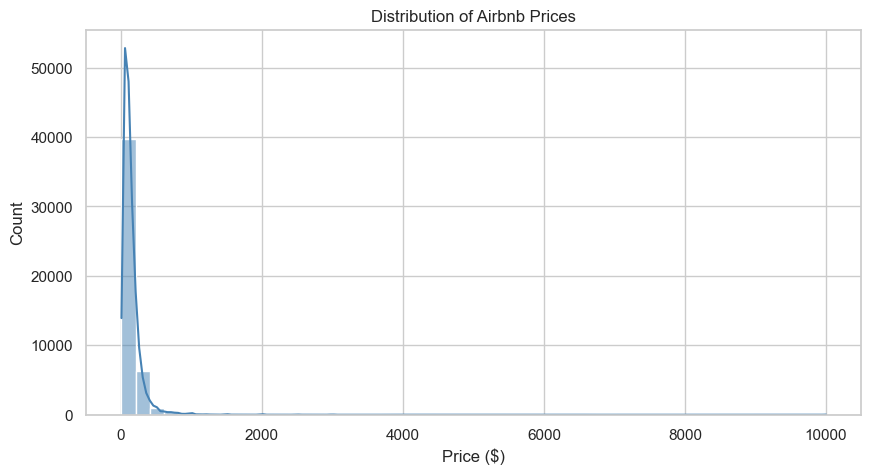

In [3]:
# Prepare histogram
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

This block of code produces a histograph representing the distribution of Airbnb prices.  

>This code presents a visualization of the Airbnb listing prices in the dataset.  
>>The size of the plot is set, ensuring it is wide enough to display the price distribution    
>>The histogram is created using the price column, dividing the data into 50 bins to show how often listings fall within each price range  
>>The kde=True argument is used to overlay a kernel density estimation curve, providing a smooth line representing the overall distribution shape  
>>The color of the histogram is set to a steel blue shade for clarity  
>>The plot includes a descriptive title and labeled axes to make interpretation easier  

>Overall, this visualization helps reveal key pricing patterns—such as skewness, outliers, and the most common price ranges—allowing to assess how prices are distributed before performing deeper analysis or building predictive models.  

Sidenotes:  
>This histogram shows a highly right-skewed distribution.  Most listings fall within the lower price ranges—generally between $0 and $300—while a long tail extends to higher-priced properties, some reaching several thousand dollars per night. 

>This pattern indicates that while the market has a large volume of affordable listings, a relatively small number of expensive or luxury properties pull the upper range outward.  The KDE curve reinforces this shape by showing a steep peak at low prices and a gradual decline as the price increases.  
>This confirms that the dataset reflects a more realistic pricing distribution after removing duplicates and cleaning earlier inconsistencies.  

Next Steps:  
For clearer analysis, I will create a trimmed dataset that keeps only listings under priced $500.  This will facilitate a study of typical pricing behavior, separate from luxury properties.

>I have chosen to filter these extreme outliers.  The high-priced listings (those over $1,000) are legitimate; however, they are rare.  These outliers distort averages and scale in visualizations.  
>>Remove the high-priced listings from the dataset  
>>Prepare revised histogram with updated dataset

Existing dataframe shape:  (47668, 8)
Number of rows with price > 500: 1021

Shape after trimming dataset to rows with price between $10 and $500:
Resulting shape: (46647, 8) 



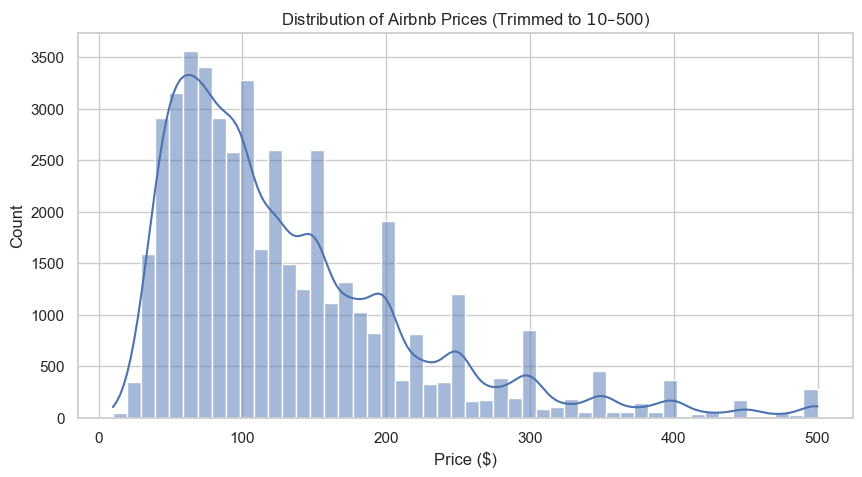

In [4]:
# Shape of existing dataframe
print("Existing dataframe shape: ", df.shape)

# To support count of luxury properties, establish pricing threshold
threshold = 500

# Filter the DataFrame to find rows where price is > 500, 
# identified as filtered_df
filtered_df = df[df["price"] > threshold]

# Count of rows in the filtered dataFrame
luxury_properties = filtered_df.shape[0] 

# Print the count of luxury properties
print(f"Number of rows with price > {threshold}: {luxury_properties}")

# Keep only listings up to a price of $500
df_trim = df[df["price"].between(10, 500)]
print("\nShape after trimming dataset to rows with price between $10 and $500:")
print("Resulting shape:", df_trim.shape, "\n")

# Produce histogram with luxury properties removed
plt.figure(figsize=(10, 5))
sns.histplot(df_trim["price"], bins=50, kde=True)
plt.title("Distribution of Airbnb Prices (Trimmed to $10–$500)")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

This block of code removes those rows with prices over 500 that have been identified as outliers.  Through the code:  
>I listed the count of rows before removal of luxury properties rows
>Then I worked to list the count rows of luxury properties
>>I established a threshold value of $500  
>>I created a filtered dataframe of those rows with a price above the threshold value
>>I then counted the number of rows in the filtered dataframe and printed the value

>Next, I established a trimmed dataframe, removing those luxury property rows  
>I then produced a histogram of the resulting, trimmed dataframe    

Sidenotes:  
This trimmed price distribution reveals a much more realistic and interpretable view of Airbnb pricing patterns.  Most listings fall between 50 and 150, forming a strong right-skewed curve with a clear peak around the lower–mid price ranges.  

As price increases beyond 150, the number of listings steadily declines.  This shows that mid-range and more budget-friendly accommodations dominate the market while higher-priced listings are relatively rare.  

Choosing to focus on the price range up to 500 dollars helps make the distribution more meaningful for analysis.  Additionally, it provides clearer insights into typical pricing behavior.  This sets a more solid foundation for comparing prices across room types, neighborhoods, and other listing attributes.

-----------------------------------------------------------------------------------------------------------------
*3. Create a boxplot*

Unique room types:
['Private room' 'Entire home/apt' 'Shared room']

Room type counts:
room_type
Entire home/apt    24090
Private room       21426
Shared room         1131
Name: count, dtype: int64 



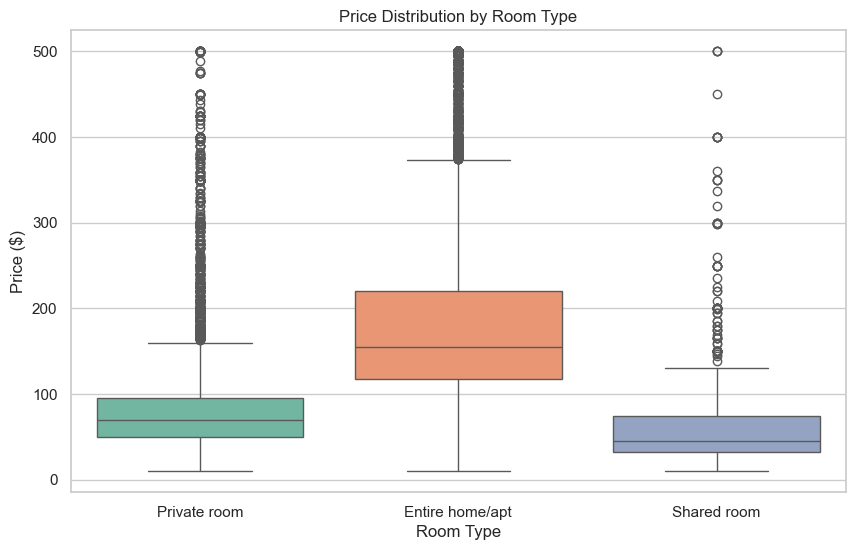

In [5]:
# Print unique room types
print("Unique room types:")
print(df_trim["room_type"].unique())

# Print counts of each room type
print("\nRoom type counts:")
print(df_trim["room_type"].value_counts(), "\n")

# Prepare boxplot
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_trim,
    x="room_type",
    y="price",
    hue="room_type",     
    palette="Set2",
    legend=False         
)
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.show()

This block of code produces a blox plot, visualizing the price distribution by room type.  
>The different room types are listed
>Counts of each different room type is listed
>The boxplot is prepared, showing how Airbnb prices differ across the three room types  
>>The median price for entire home/apt listings is significantly higher compared to private and shared room - this is to be expected  
>>This category displays the widest interquartile range (IQR), which indicates variability in pricing and a broader mix of budget, mid-range, and premium listings.    

Sidenotes:  
>Both Private rooms and Shared rooms show lower and more tightly clustered price ranges, with Shared rooms having the lowest median price overall.  
>All three categories display numerous outliers—listings priced substantially above the typical range—which is common in Airbnb markets, especially in high-demand or luxury areas, like NYC.

Overall, the boxplot confirms that room type is a strong differentiator in pricing and that entire homes command substantially higher rates with greater pricing diversity.

-----------------------------------------------------------------------------------------------------------------
*4. Create a bivariate plot*

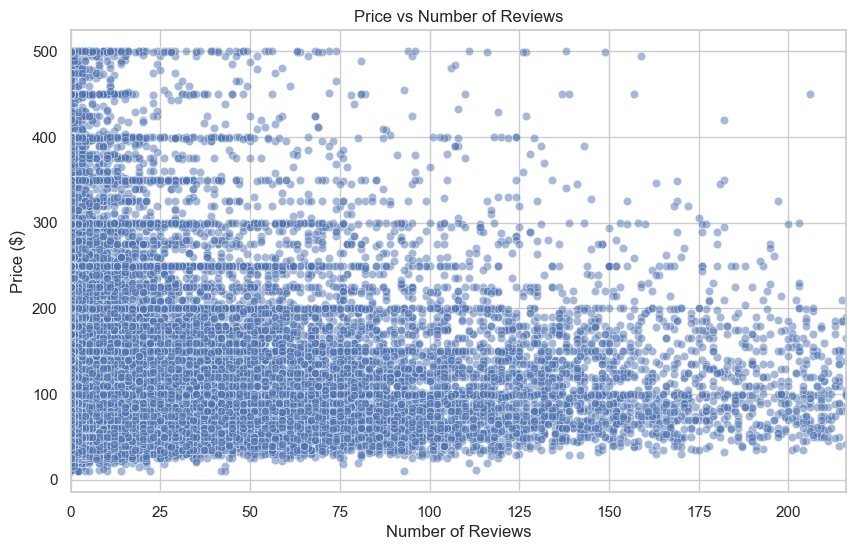

In [6]:
# Prepare bivariate plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_trim, x="number_of_reviews", y="price", alpha=0.5)
plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")
plt.xlim(0, df_trim["number_of_reviews"].quantile(0.99))
plt.show()

This block of code produces a bivariate plot visualizing price versus number of reviews.  
>A bivariate plot is used to visualize and analyze the relationship between two variables.  This helps to identify trends, patterns, and correlations (positive, negative, or none).  This information is crucial for making predictions and understanding how one variable might influence another.  In this case, how price may influence the reviewer to post a review.

This code generates a scatter plot that visualizes the relationship between Airbnb listing price and the number of reviews.  
>The plot is sized to 10×6 inches for readability  
>Each point represents a listing  
>The alpha=0.5 parameter makes the points semi-transparent, so dense clusters are easier to see when many listings overlap   
>The title and axis labels help clarify what the plot represents  
>The plot restricts the x-axis to the 99th percentile of number of reviews  
>>This removes extreme outliers (those highly reviewed listings that could stretch the axis and compress the bluk of the data  
>>***Note***: Focusing on the typical range of review counts ensures the plot presents a clearer picture of the main trend between price and review volume    


Sidenotes:  

This scatter plot shows the relationship between Airbnb listing price and the number of reviews. The distribution reveals that there is no strong linear relationship between the two variables.  
>This means that higher-priced listings do not necessarily have more or fewer reviews.  
>Most listings with numerous reviews fall within the lower price ranges, generally below $200.
>>This suggests that budget-friendly or moderately priced properties tend to attract more guests, which naturally leads to more accumulated reviews over time.  

>Higher-priced listings (above $300) appear much less frequently and tend to have fewer reviews.  
>This is expected because expensive listings attract a narrower audience and are booked less often.  
>The dense cluster near lower prices and low-to-moderate review counts confirms that the Airbnb market is driven largely by affordable and mid-range options.  

Overall, the plot exhibits a negative trend - as the price increases, the number of reviews generally decreases; however, the relationship is weak and scattered.  This indicates that many other factors (location, room type, availability) also influence review volume.

-----------------------------------------------------------------------------------------------------------------
*5. Create any additional visualizations that will help to answer the questions to answer.*

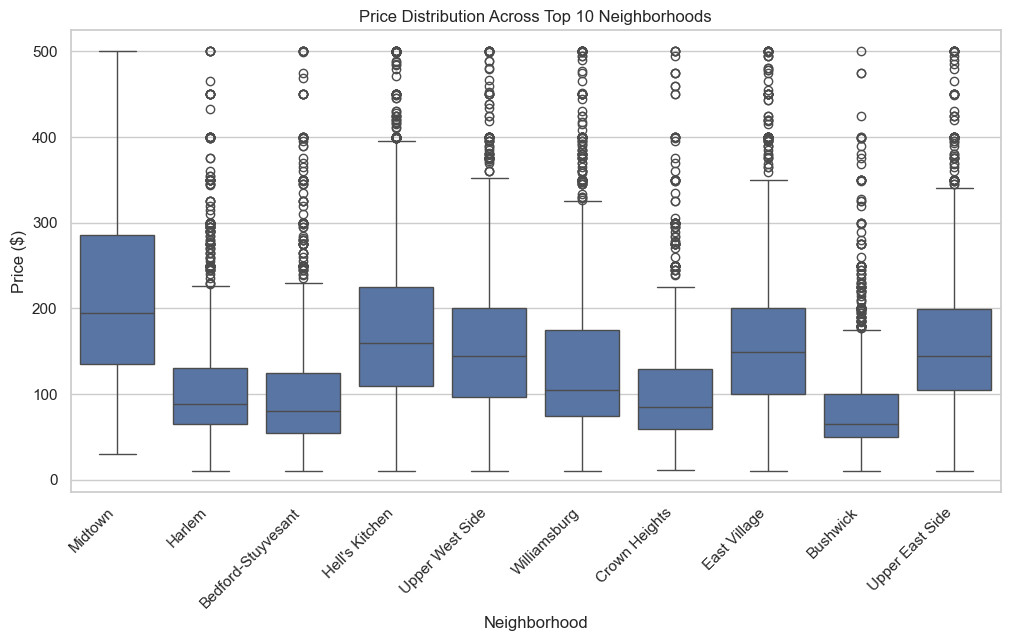

In [7]:
# Top 10 neighborhoods with most listings
top10 = df_trim["neighbourhood"].value_counts().head(10).index
df_top10 = df_trim[df_trim["neighbourhood"].isin(top10)]

# Additional boxplot graph
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top10, x="neighbourhood", y="price")
plt.title("Price Distribution Across Top 10 Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Price ($)")
plt.xticks(rotation=45, ha="right")
plt.show()

This block of code identifies the top 10 neighborhoods with the highest number of Airbnb listings then visualizes how prices vary across those neighborhoods.  
>Counts how many listings belong to each neighborhood, selecting the top 10 neighborhoods  
>The dataset is then filtered to include only listings from these neighborhoods  
>>This produces a new DataFrame reflecting ontaining the most Airbnb areas  

>Another boxplot is created to compare price distributions across these top neighborhoods
>>Each neighborhood appears on the x-axis
>>Its responding price distribution appears on the y-axis

>The boxplot highlights key statistical properties—median price, interquartile range (IQR), and outliers—for each neighborhood
>The axis labels and rotated tick labels improve readability, especially when neighborhood names are long

Sitenotes:  
The choice of the final boxplot proved significant in the analysis of price distribution.  
>Analyzing price distribution across the top 10 neighborhoods provides important context that the overall price histogram and room-type boxplots cannot capture.  
>>Neighborhood is one of the strongest determinants of Airbnb pricing because it reflects factors such as proximity to attractions, safety, demand, and local housing costs.

>>By focusing on the neighborhoods with the most listings, the analysis highlights where Airbnb activity is concentrated and how pricing behavior differs across high-demand areas.  

The boxplot reveals how location influences Airbnb pricing. 
>Some neighborhoods show higher median prices and wider spreads.  This indicates a stronger demand with diverse listing types or the presence of premium accommodations.  
>Other neighborhoods display tighter price ranges, suggesting a more uniform market and fewer high-priced outliers.  
>The presence of substantial price variability in certain areas highlights how neighborhood desirability and local housing conditions shape pricing patterns.  

Overall, this plot confirms that neighborhood is a significant factor in determining listing price and should be considered an important feature in both exploratory analysis and any predictive modeling that follows.  

-----------------------------------------------------------------------------------------------------------------
*6. Summarize results and make a conclusion, explaining this conclusion and the chosen visualizations that support the conclusion.*

Summary of Results
Findings  
>Q1: What is the distribution of prices?  

>>The histogram shows that most Airbnb listings are priced between 50 and 200 dollars, with a long right-tail extending toward higher-price luxury listings.  
>>This indicates strong affordability variation, but most listings fall within a typical short-stay price range.  

>Q2: How do prices vary by room type?  
 
>The boxplot reveals clear differences, indicating that room type is a major factor influencing price:

>>Entire homes/apartments have the highest median price  
>>Private rooms are significantly cheaper  
>>Shared rooms are the lowest-cost option

>Q3: Is there a relationship between price and number of reviews?  

>The scatterplot shows a weak negative relationship, suggesting budget listings attract a broader customer base and higher turnover:
>>Lower-priced listings tend to have more reviews
>>Higher-priced listings tend to have fewer reviews  

>Q4: What is the relationship between the price and the location of the Airbnb?

>The boxplot reveals whether certain neighborhoods have higher prices, a greater price variability, or attract different types of listings:
>>The neighborhood boxplot shows significant price differences based on location.
>>Touristy or high-demand neighborhoods cluster at higher prices.  

Conclusion
>Based on the visualizations:  
>>Most Airbnb listings fall into a moderate price range, indicating affordability for typical visitors.  
>>Room type strongly influences price, with entire homes being the most expensive.  
>>Cheaper listings accumulate more reviews, suggesting higher occupancy rates.  
>>Neighborhood location also plays a large role in determining price, especially in tourist-heavy areas.  

>These conclusions were supported by the histogram (price distribution), boxplot (price by room type), scatterplot (price vs reviews), and additional location-based visualizations.

Sidenotes Summary:  

The trimmed price distribution of the histogram visualization reveals a much more realistic and interpretable view of Airbnb pricing patterns. Most listings fall between 50 and 150, forming a strong right-skewed curve with a clear peak around the lower–mid price ranges.  

The first boxplot visualization confirms that room type is a strong differentiator in pricing and that entire homes command substantially higher rates with greater pricing diversity.  

This scatter plot illustrates the relationship between Airbnb listing price and the number of reviews, indicating that there is no strong linear correlation between the two variables.  

My final boxplot observation extends my analysis as it reveals whether certain neighborhoods have higher prices, a greater price variability, or attract different types of listings.  It also helps identify potential outliers or pricing anomalies unique to specific neighborhoods.  It is valuable to understand these patterns to gain insights and confirm whether location should be treated as a key feature influencing price.  

Recommendations for further analysis:  
Now that you have a clearer understanding of how price behaves in relation to room type, reviews, and neighborhood, the next step is to expand your EDA to uncover additional patterns. Consider exploring:

Price vs. availability (Do more available listings tend to be cheaper or more expensive?)

Price vs. minimum nights (Higher minimum nights may correlate with specific pricing tiers.)

Review behavior across neighborhoods to understand guest demand trends.

Correlation matrix to quantify relationships between numerical variables.

-----------------------------------------------------------------------------------------------------------------
Follow on steps to support providing predictive insights for a potential Airbnb host include:

>Build a predictive pricing model that estimates a reasonable nightly rate
>>Based on features such as room type, neighborhood, availability, and review activity
>>Training regression models such as Linear Regression, Random Forest, or Gradient Boosting to predict what similar listings charge and provide a new host with an evidence-based price recommendation for their unit

>In addition to pricing, a host may want to understand how often their property might be booked.  Using variables like reviews per month and availability patterns to create models that estimate:
>>Expected demand to help anticipate occupancy trends
>>Identify which types of listings attract consistent guest traffic  

>I would also utilize clustering techniques to categorize listings into market segments such as budget rentals, mid-range entire homes, or high-end luxury units.  This would help a prospective host understand where their property would fit within the local market and whether competing listings follow similar pricing and demand patterns.  

>Finally, I would recommend estimating potential revenue by combining predicted nightly price with expected occupancy rates.  This would transform the analysis into practical guidance, allowing hosts to forecast monthly or yearly income. Together, these predictive components make the project more valuable by offering clear, data-driven insights for anyone considering entering the Airbnb market.  